# XWorld — Dataset 1: COVID-19 First Wave

**Goal**: Download country-level COVID case curves, extract first-wave slices, z-score normalize, compute 7 shape features per country, and visually verify before any clustering.

**Dynamic type being captured**: Logistic / epidemic growth curve

## 1. Imports

In [1]:
import requests
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

print('Imports OK')

Imports OK


## 2. Download OWID COVID data

In [2]:
URL = 'https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv'
dest = RAW_DIR / 'owid_covid.csv'

if not dest.exists():
    print('Downloading... (~70MB, takes a moment)')
    r = requests.get(URL, stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f'Saved to {dest}')
else:
    print(f'Already exists: {dest}')

Downloading... (~70MB, takes a moment)
Saved to ../data/raw/owid_covid.csv


## 3. Load and inspect

In [3]:
df_raw = pd.read_csv(
    dest,
    usecols=['location', 'date', 'new_cases_smoothed_per_million', 'continent'],
    parse_dates=['date']
)

print(f'Rows: {len(df_raw):,}')
print(f'Countries: {df_raw.location.nunique()}')
print(f'Date range: {df_raw.date.min().date()} to {df_raw.date.max().date()}')
df_raw.head()

Rows: 429,435
Countries: 255
Date range: 2020-01-01 to 2024-08-14


,continent,location,date,new_cases_smoothed_per_million
0,Asia,Afghanistan,2020-01-05,NaN
1,Asia,Afghanistan,2020-01-06,NaN
2,Asia,Afghanistan,2020-01-07,NaN
3,Asia,Afghanistan,2020-01-08,NaN
4,Asia,Afghanistan,2020-01-09,NaN


## 4. Filter to real countries (drop aggregates like 'World', 'Europe', etc.)

In [4]:
# OWID includes continent/income aggregates — drop them (they have no continent value)
df = df_raw.dropna(subset=['continent']).copy()
df = df.rename(columns={'new_cases_smoothed_per_million': 'cases_pm'})

print(f'Countries after removing aggregates: {df.location.nunique()}')

Countries after removing aggregates: 243


## 5. Extract first wave per country

Definition: from first date cases_pm > 0.5 to first local minimum after the first peak.
Window capped at 180 days max to keep series comparable in length.

In [15]:
def extract_first_wave(series: pd.Series, max_days: int = 180, min_days: int = 30) -> np.ndarray | None:
    """
    Given a daily cases_pm series (already sorted by date),
    extract the first wave as a numpy array.
    Returns None if the series is too short or has no clear peak.
    """
    s = series.fillna(0).values

    # Find start: first day cases exceed threshold
    threshold = 0.5
    starts = np.where(s > threshold)[0]
    if len(starts) == 0:
        return None
    start = starts[0]

    # Cap at max_days from start
    end = min(start + max_days, len(s))
    wave = s[start:end]

    if len(wave) < min_days:
        return None

    # Must have at least one meaningful peak
    peaks, _ = find_peaks(wave, prominence=wave.max() * 0.2)
    if len(peaks) == 0:
        return None

    # Trim to first peak + some tail (up to 60 days after peak)
    first_peak = peaks[0]
    trim_end = min(first_peak + 60, len(wave))
    wave = wave[:trim_end]

    if len(wave) < min_days:
        return None

    return wave


waves = {}
for country, grp in df.groupby('location'):
    grp = grp.sort_values('date')
    wave = extract_first_wave(grp['cases_pm'])
    if wave is not None:
        waves[country] = wave

print(f'Countries with usable first wave: {len(waves)}')

Countries with usable first wave: 202


## 6. Visual check — plot a sample of waves before normalizing

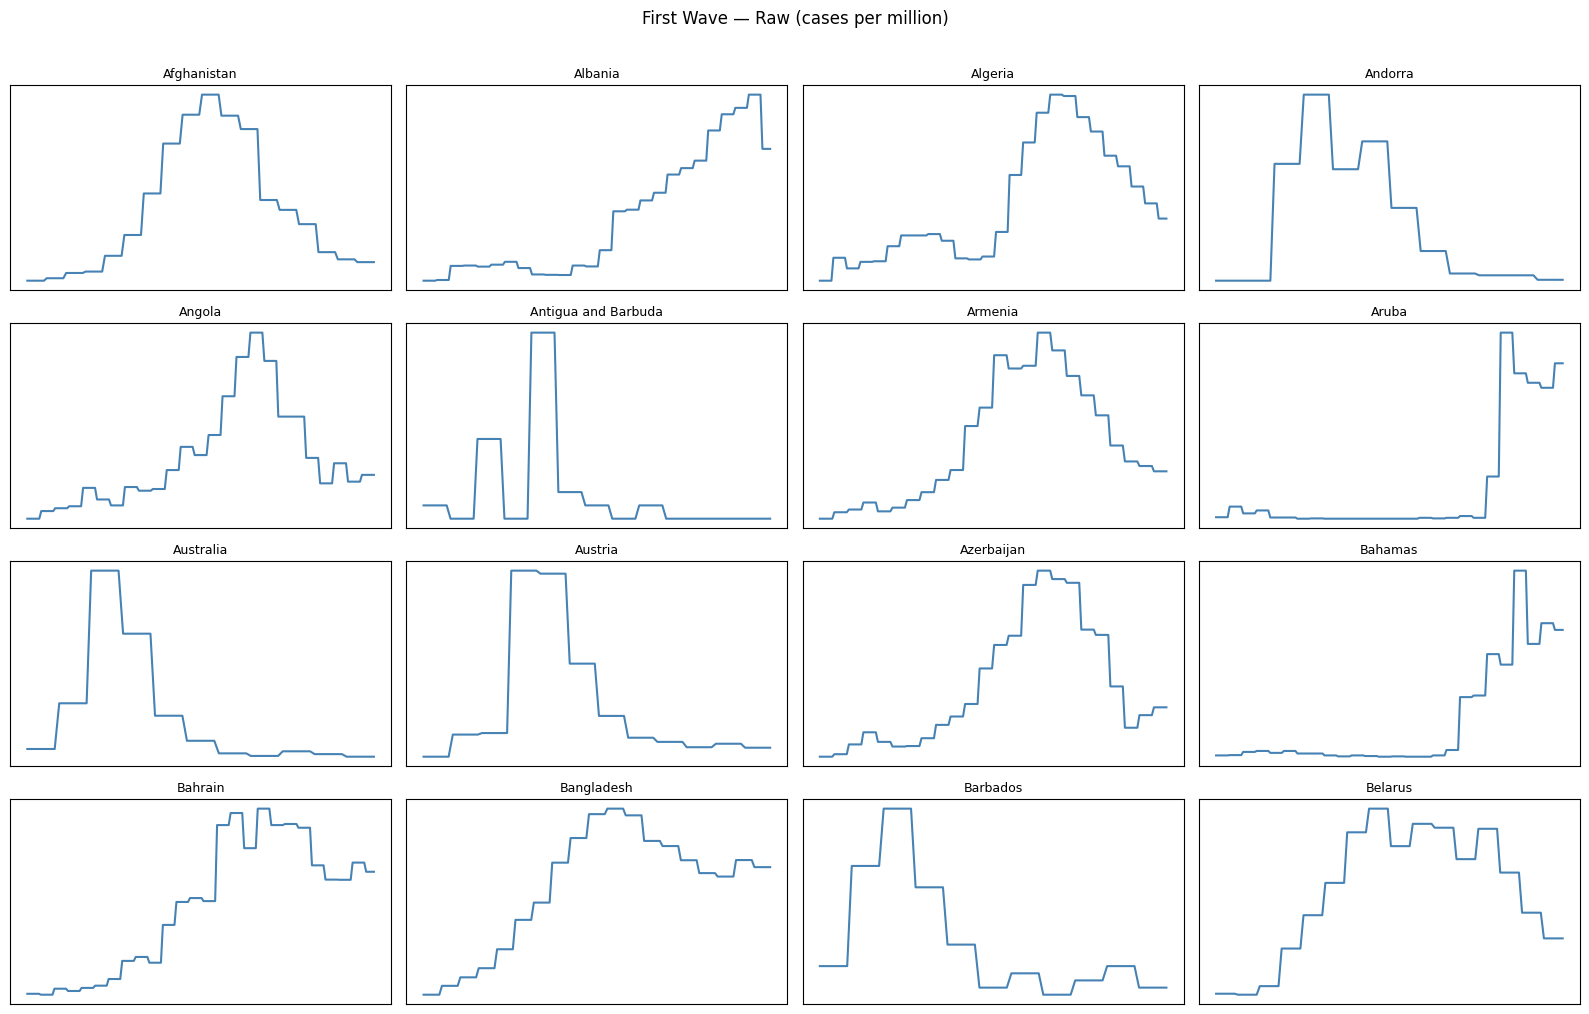

In [6]:
sample_countries = list(waves.keys())[:16]
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.flatten()

for i, country in enumerate(sample_countries):
    axes[i].plot(waves[country], color='steelblue', linewidth=1.5)
    axes[i].set_title(country, fontsize=9)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle('First Wave — Raw (cases per million)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'covid_waves_raw_sample.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Z-score normalize each wave

In [13]:
def zscore_normalize(series: np.ndarray) -> np.ndarray:
    mean = series.mean()
    std = series.std()
    if std == 0:
        return series - mean
    return (series - mean) / std


waves_norm = {country: zscore_normalize(wave) for country, wave in waves.items()}

# Verify — use first available country rather than hardcoding
sample_country = next(iter(waves_norm))
sample = waves_norm[sample_country]
print(f'{sample_country} normalized — mean: {sample.mean():.4f}, std: {sample.std():.4f}')
print(f'Total countries normalized: {len(waves_norm)}')

Afghanistan normalized — mean: 0.0000, std: 1.0000
Total countries normalized: 202


## 8. Visual check — normalized waves overlaid (should now be shape-comparable)

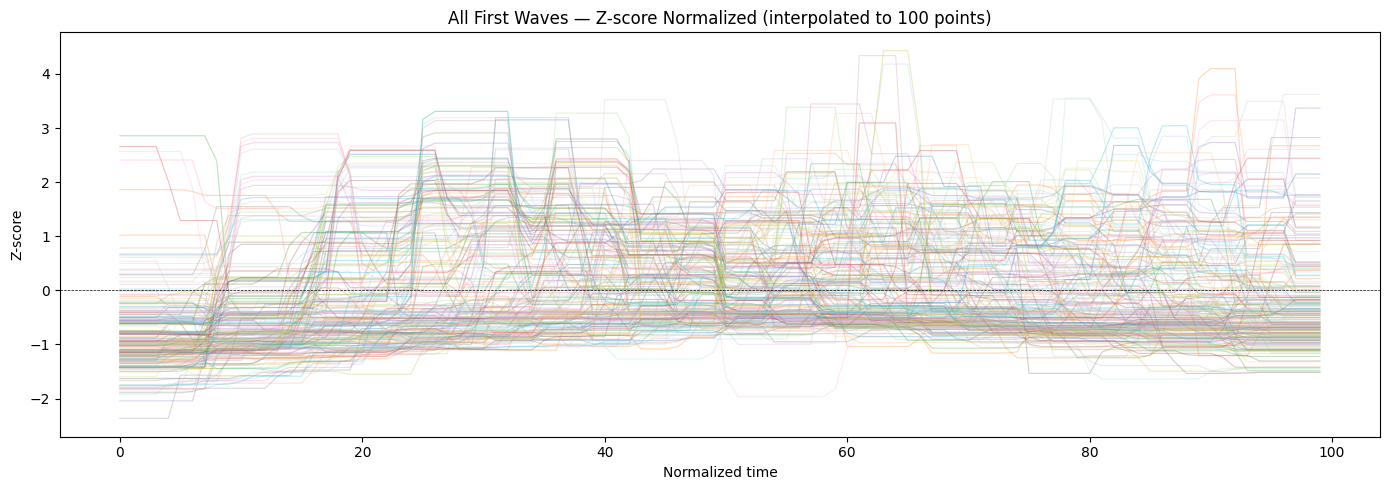

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = cm.tab20(np.linspace(0, 1, len(waves_norm)))
for (country, wave), color in zip(waves_norm.items(), colors):
    # Interpolate to common length 100 for overlay
    x_orig = np.linspace(0, 1, len(wave))
    x_new = np.linspace(0, 1, 100)
    wave_interp = np.interp(x_new, x_orig, wave)
    ax.plot(wave_interp, alpha=0.3, linewidth=0.8, color=color)

ax.set_title('All First Waves — Z-score Normalized (interpolated to 100 points)', fontsize=12)
ax.set_xlabel('Normalized time')
ax.set_ylabel('Z-score')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'covid_waves_normalized_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Extract 7 shape features per series

In [9]:
def extract_features(series: np.ndarray) -> dict:
    """
    7 shape features from a z-score normalized time series.
    These describe the dynamic signature independent of scale and domain.
    """
    n = len(series)
    t = np.arange(n)

    # Lag-1 autocorrelation: how much does the next step look like this step
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0

    # Zero crossing rate: proxy for oscillation frequency
    zero_crossings = np.sum(np.diff(np.sign(series)) != 0) / n

    # Linear slope: is the series trending up, down, or flat overall
    slope = stats.linregress(t, series).slope

    return {
        'mean':           series.mean(),          # ~0 after z-score; residual drift shows here
        'std':            series.std(),            # ~1 after z-score; spread within window
        'skewness':       stats.skew(series),      # asymmetry — epidemic curves are right-skewed
        'kurtosis':       stats.kurtosis(series),  # peak sharpness vs flat
        'lag1_autocorr':  lag1,                    # smoothness / persistence
        'zero_crossings': zero_crossings,          # oscillation frequency proxy
        'slope':          slope,                   # directional drift over full window
    }


records = []
for country, wave in waves_norm.items():
    feats = extract_features(wave)
    feats['country'] = country
    feats['dataset'] = 'covid_first_wave'
    feats['n_points'] = len(wave)
    records.append(feats)

df_features = pd.DataFrame(records)
print(f'Feature matrix shape: {df_features.shape}')
df_features.head()

Feature matrix shape: (202, 10)


,mean,std,skewness,kurtosis,lag1_autocorr,zero_crossings,slope,country,dataset,n_points
0,2.114711e-16,1.0,0.600701,-1.132311,0.986649,0.015873,0.005839,Afghanistan,covid_first_wave,126
1,0.000000e+00,1.0,0.698114,-0.956794,0.994699,0.005556,0.017564,Albania,covid_first_wave,180
2,-2.368476e-16,1.0,0.581746,-1.101089,0.992110,0.011111,0.013763,Algeria,covid_first_wave,180
3,3.172066e-17,1.0,0.724967,-0.935223,0.952951,0.023810,-0.015057,Andorra,covid_first_wave,84
4,-2.436147e-16,1.0,1.043710,0.097697,0.985470,0.011429,0.010140,Angola,covid_first_wave,175


## 10. Inspect feature distributions

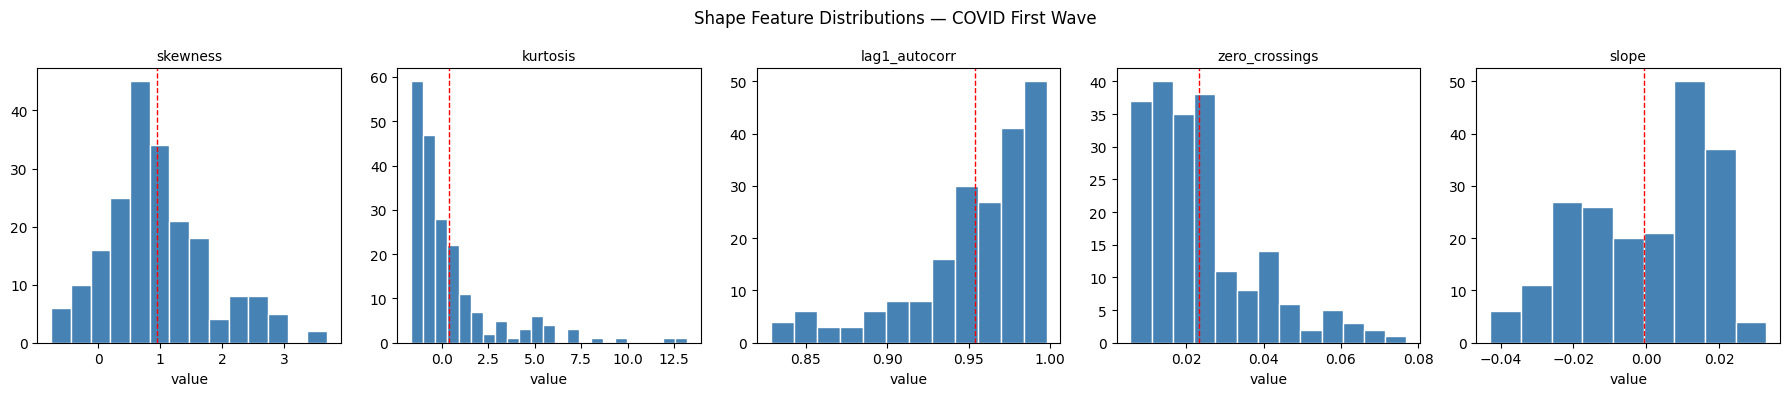


All 7 features summary:


,mean,std,skewness,kurtosis,lag1_autocorr,zero_crossings,slope
count,202.0,202.0,202.000,202.000,202.000,202.000,202.000
mean,-0.0,1.0,0.950,0.412,0.954,0.023,-0.001
std,0.0,0.0,0.838,2.472,0.040,0.015,0.018
min,-0.0,1.0,-0.756,-1.660,0.828,0.006,-0.043
25%,-0.0,1.0,0.426,-1.074,0.940,0.012,-0.015
50%,0.0,1.0,0.825,-0.444,0.965,0.020,0.005
75%,0.0,1.0,1.377,0.833,0.984,0.029,0.015
max,0.0,1.0,3.688,13.197,0.998,0.077,0.033


In [14]:
# mean and std are ~constant after z-scoring — not informative to plot
# plot only the 5 features that carry shape information
plot_cols = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(plot_cols):
    axes[i].hist(df_features[col], bins='auto', color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].axvline(df_features[col].mean(), color='red', linestyle='--', linewidth=1, label='mean')
    axes[i].set_xlabel('value')

plt.suptitle('Shape Feature Distributions — COVID First Wave', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'covid_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nAll 7 features summary:')
feature_cols = ['mean', 'std', 'skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
df_features[feature_cols].describe().round(3)

## 11. Save feature matrix

In [11]:
out_path = PROCESSED_DIR / 'features_covid_first_wave.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'\nShape: {df_features.shape}')
print(f'Countries: {df_features.country.nunique()}')
print('\nFeature summary:')
print(df_features[feature_cols].describe().round(3))

Saved: ../data/processed/features_covid_first_wave.csv

Shape: (202, 10)
Countries: 202

Feature summary:
        mean    std  skewness  kurtosis  lag1_autocorr  zero_crossings  \
count  202.0  202.0   202.000   202.000        202.000         202.000   
mean    -0.0    1.0     0.950     0.412          0.954           0.023   
std      0.0    0.0     0.838     2.472          0.040           0.015   
min     -0.0    1.0    -0.756    -1.660          0.828           0.006   
25%     -0.0    1.0     0.426    -1.074          0.940           0.012   
50%      0.0    1.0     0.825    -0.444          0.965           0.020   
75%      0.0    1.0     1.377     0.833          0.984           0.029   
max      0.0    1.0     3.688    13.197          0.998           0.077   

         slope  
count  202.000  
mean    -0.001  
std      0.018  
min     -0.043  
25%     -0.015  
50%      0.005  
75%      0.015  
max      0.033  


---
## Status

- COVID first wave extracted and features computed
- Next: `02_sunspot_pipeline.ipynb` — cyclic oscillation dataset
- Clustering happens in `05_cluster_all.ipynb` once all datasets are processed